In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# Carga de datos
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df = pd.read_csv(url)

EDA

In [2]:
print("Primeras 5 filas del dataset:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())

Primeras 5 filas del dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null 

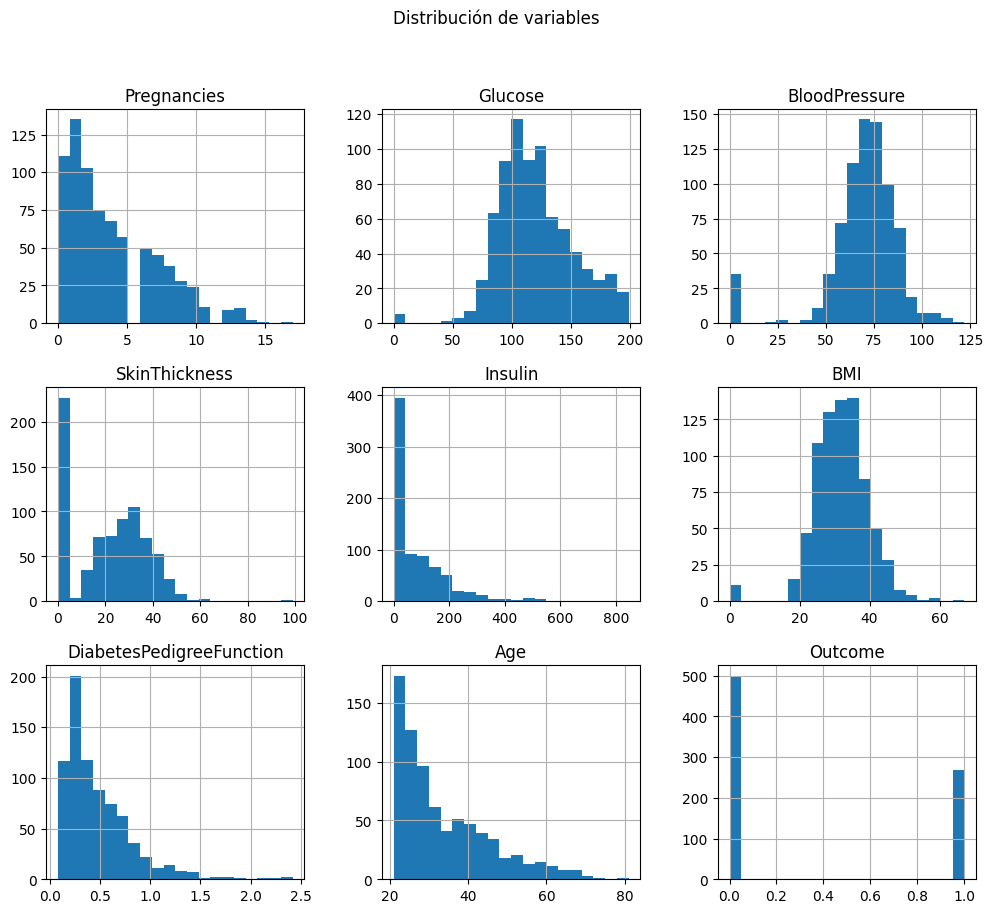

In [3]:
# Histograma de cada variable para entender la distribución
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Distribución de variables")
plt.show()


- Análisis: Algunas variables como Age o DiabetesPedigreeFunction tienen una "cola" larga a la derecha (sesgo positivo), lo que significa que la mayoría de pacientes son jóvenes o tienen valores bajos en esa función. 

-Esto ayuda a ver si los datos están muy concentrados en rangos específicos.

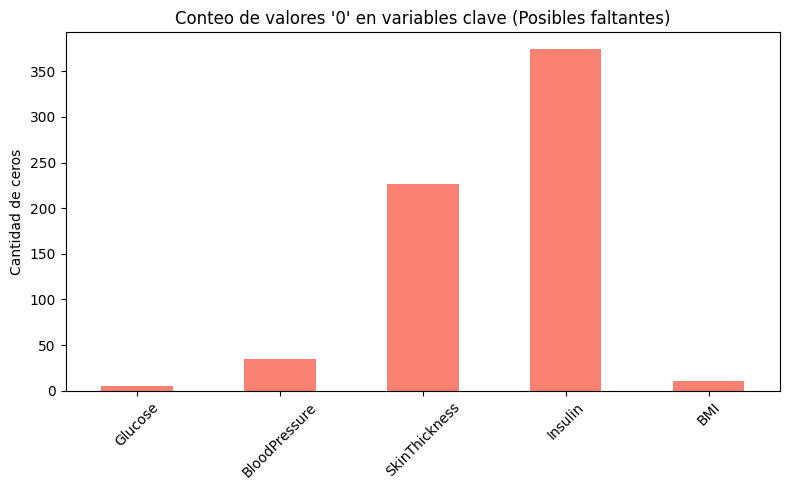

In [4]:
# visualizacion de ceros en variables clave
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
conteo_ceros = (df[cols_con_ceros] == 0).sum()

plt.figure(figsize=(8, 5))
conteo_ceros.plot(kind='bar', color='salmon')
plt.title("Conteo de valores '0' en variables clave (Posibles faltantes)")
plt.ylabel("Cantidad de ceros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Análisis: Las columnas Insulin y SkinThickness tienen muchísimos ceros. 

- Conclusión: Esos ceros son errores o datos faltantes. Si se entrena el modelo con ellos, se confundirá. Se necesita reemplazarlos por la mediana, antes de continuar.

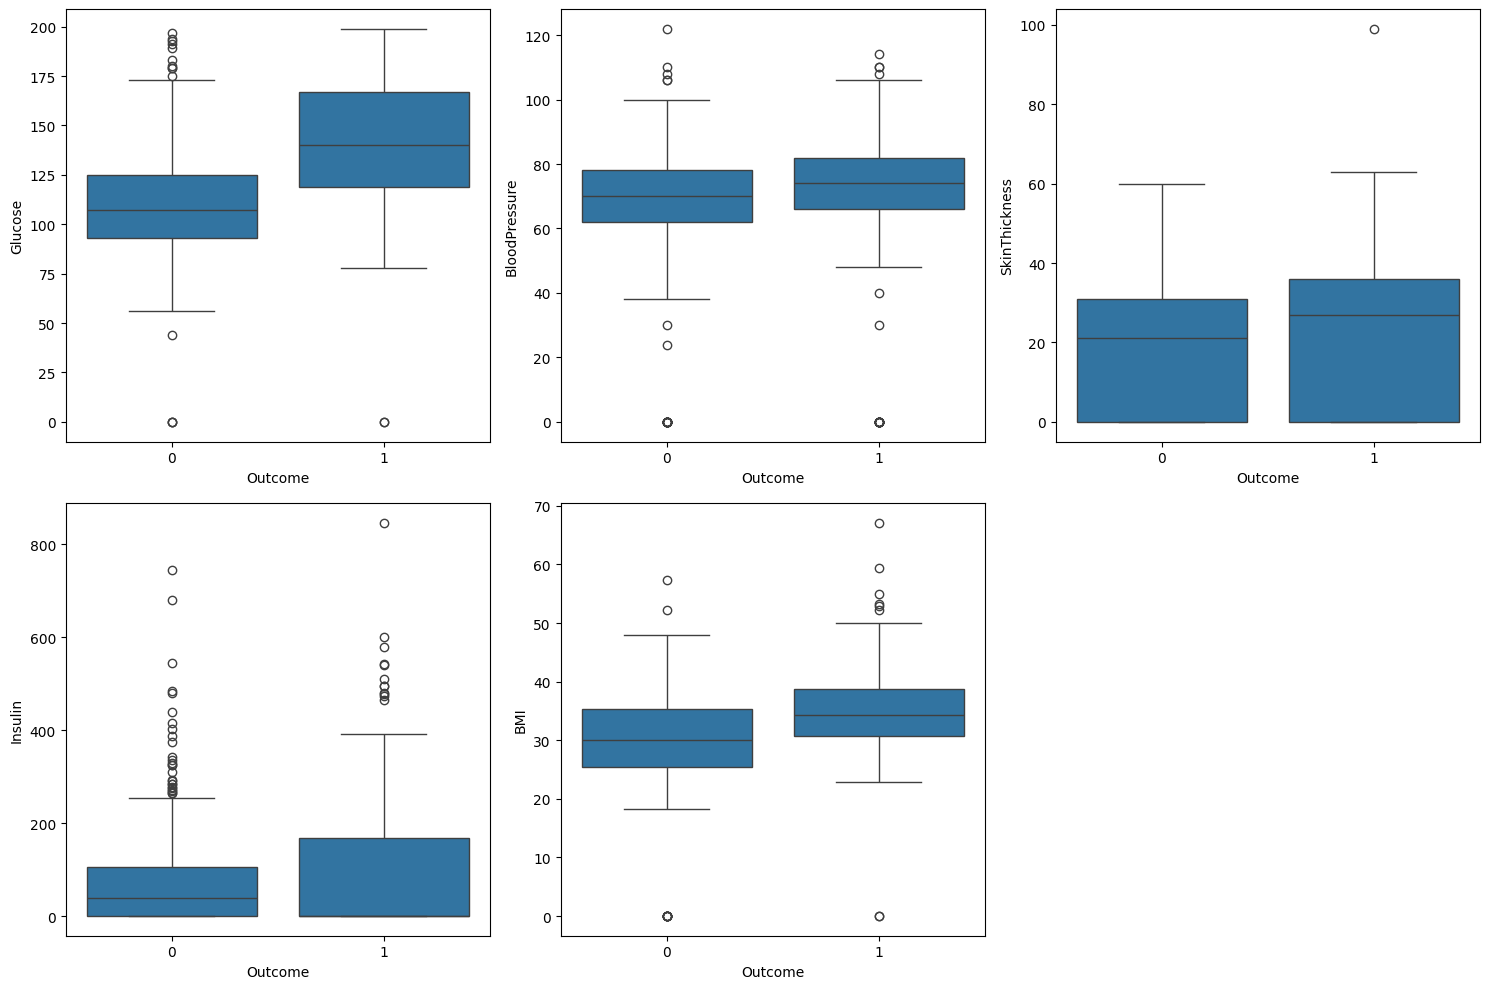

In [5]:
# Boxplots para comparar distribución según el resultado (Outcome)
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_con_ceros):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Outcome', y=col, data=df)
plt.tight_layout()
plt.show()

- Análisis: La caja de los que tienen diabetes (1) está claramente más alta. 

-Conclusión: La glucosa es un factor determinante para distinguir quién tiene diabetes.

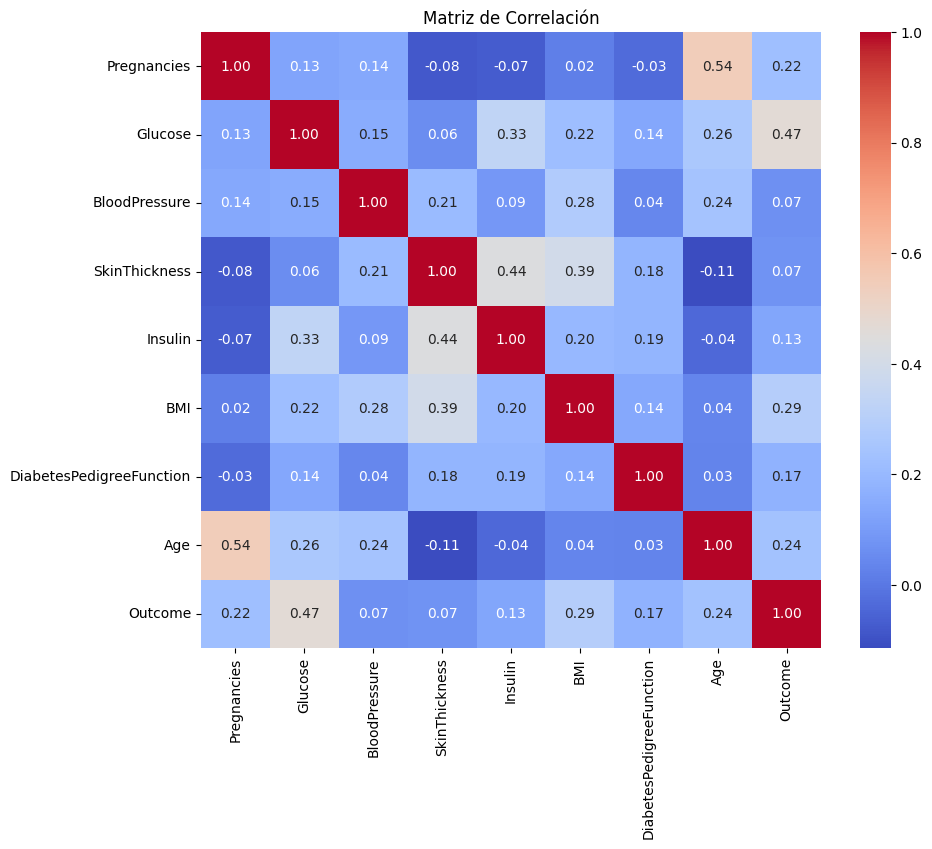

In [6]:
# Matriz de Correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

- Análisis:

-1.00 (rojo oscuro) es que son iguales.

-La variable Glucose tiene una correlación de 0.47 (es la más alta). 
-Conclusión: Si se decide elegir solo una variable para predecir, la glucosa es la mejor opción.

Feature Engineering

In [8]:
# Reemplazar los ceros por la mediana en las columnas afectadas
for col in cols_con_ceros:
    mediana = df[col].median()
    df[col] = df[col].replace(0, mediana)


In [9]:
# División en variables predictoras (X) y objetivo (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 614 muestras
Conjunto de prueba: 154 muestras


Construcción y Entrenamiento del modelo

In [39]:
# se prueban ambos criterios de pureza
criterios = ['gini', 'entropy']

for criterio in criterios:
    clf = DecisionTreeClassifier(criterion=criterio, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"\nResultados con criterio '{criterio}':")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Resultados con criterio 'gini':
Accuracy: 0.7273

Resultados con criterio 'entropy':
Accuracy: 0.7273


In [11]:
# Optimización con "Grid Search"

print("\nIniciando optimización con Grid Search...")
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5)
grid.fit(X_train, y_train)

print("Mejores parámetros encontrados:", grid.best_params_)
mejor_modelo = grid.best_estimator_




Iniciando optimización con Grid Search...
Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}


Guardar el modelo

In [12]:
filename = 'modelo_diabetes.pkl'
pickle.dump(mejor_modelo, open(filename, 'wb'))
print(f"\nModelo optimizado guardado como '{filename}'.")



Modelo optimizado guardado como 'modelo_diabetes.pkl'.


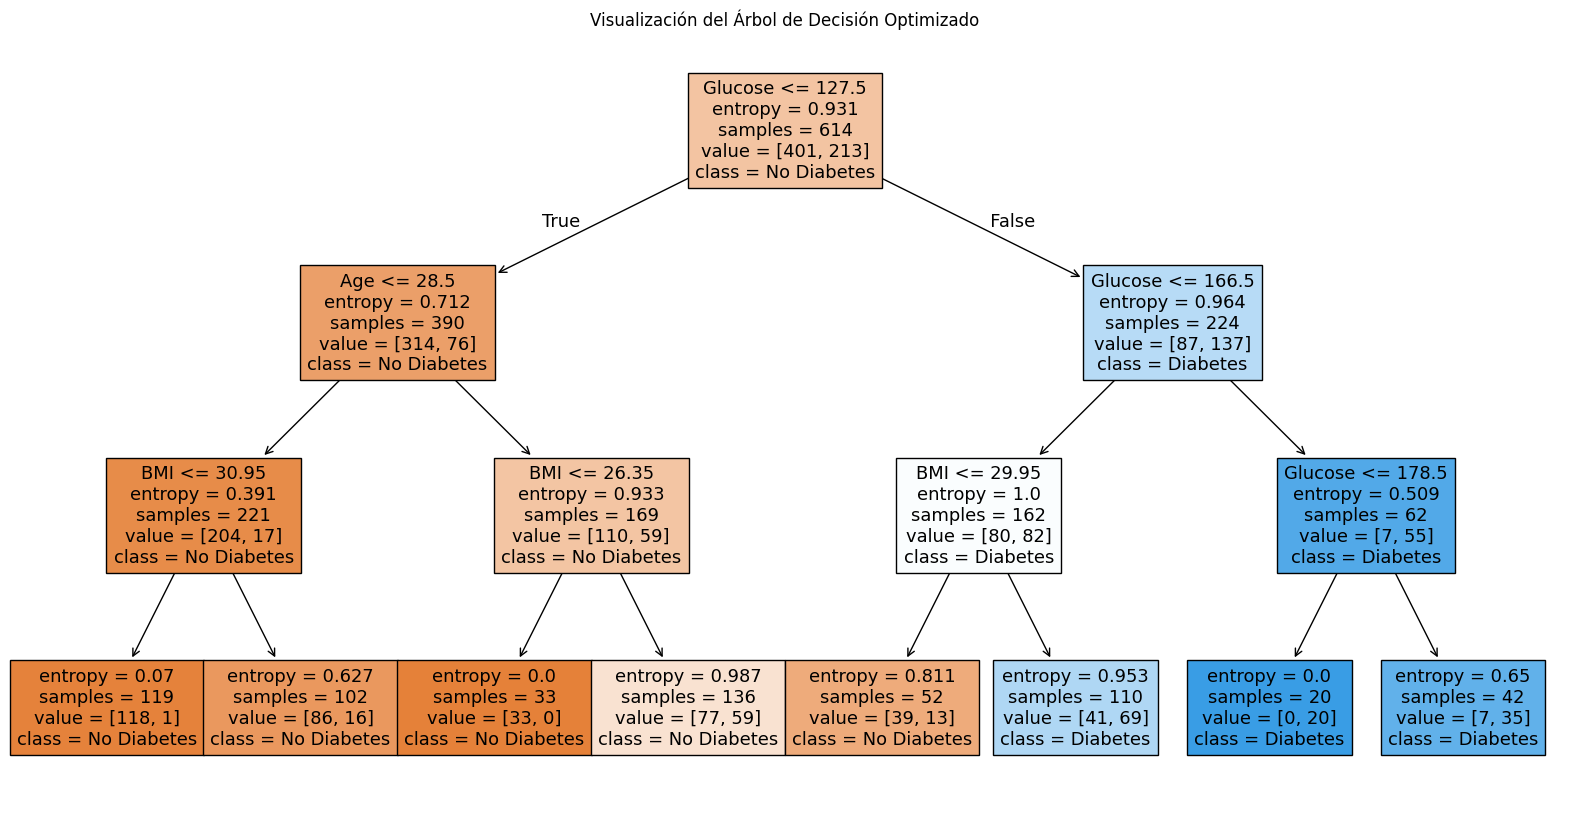

In [13]:
# Visualización del árbol resultante
plt.figure(figsize=(20, 10))
plot_tree(mejor_modelo, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.title("Visualización del Árbol de Decisión Optimizado")
plt.show()

# Random forest

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

 - NOTA: No es necesario cargar el CSV nuevamente ya que estamos en el mismo entorno de ejecución que el ejercicio anterior y el DataFrame 'df' ya está en memoria.

- Aclaración: Los datos ya han sido pre-procesados y limpiados en el ejercicio anterior

In [97]:
# EDA
# será pequeño y consiso, enfocándonos en aspectos clave para la modelización. ya que se hizo un EDA más detallado en el ejercicio anterior, aquí nos centraremos en aspectos clave para la modelización.
print("Resumen estadístico básico:")
print(df.describe())

Resumen estadístico básico:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      27.334635   94.652344   
std       3.369578   30.438286      12.096642       9.229014  105.547598   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      23.000000   30.500000   
50%       3.000000  117.000000      72.000000      23.000000   31.250000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.450911                  0.471876   33.240885    0.348958  
std      6.875366                  0.331329   11.760232    0.476951  
min    

In [98]:
# Limpieza básica para asegurar consistencia
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_con_ceros:
    df[col] = df[col].replace(0, df[col].median())

X = df.drop('Outcome', axis=1)
y = df['Outcome']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [99]:
# Cargar los modelos guardados
modelo_arbol = pickle.load(open('modelo_diabetes.pkl', 'rb'))
modelo_rf = pickle.load(open('modelo_random_forest_diabetes.pkl', 'rb'))


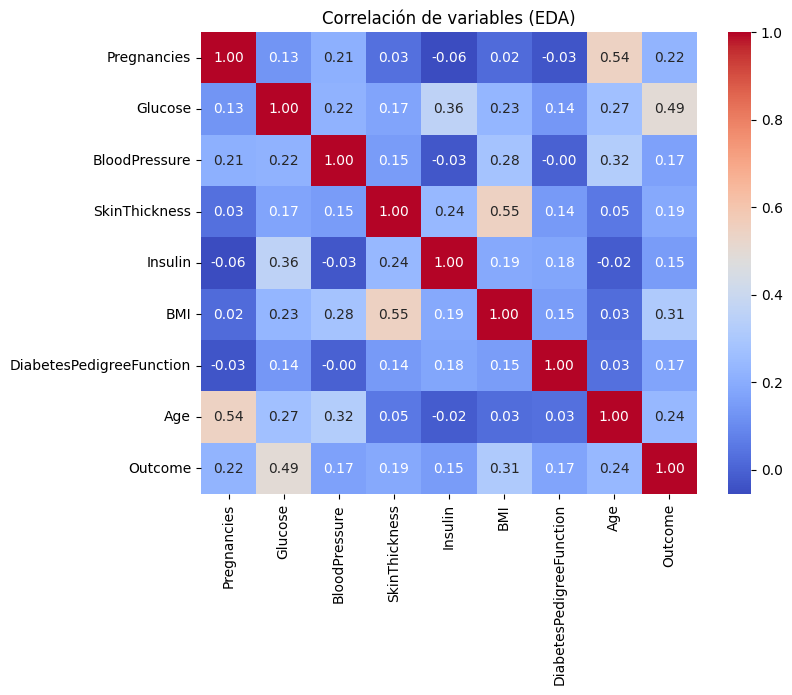

In [100]:
# Matriz de correlación para ver qué variables afectan más al 'Outcome'
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación de variables (EDA)")
plt.show()


Análisis: Tras la limpieza de datos (reemplazar ceros por la mediana), las correlaciones son 
más fiables, ya que hemos eliminado el ruido causado por valores artificiales en el dataset. 

- Antes la glucosa era 0.47, ahora 0.49

In [102]:
# Calcular métricas para ambos modelos
# se obtienen las predicciones
pred_arbol = modelo_arbol.predict(X_test)
pred_rf = modelo_rf.predict(X_test)

In [103]:
# accuracy 
acc_arbol = accuracy_score(y_test, pred_arbol)
acc_rf = accuracy_score(y_test, pred_rf)


In [104]:
# preparacion de datos para modelización
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [105]:
# Construcción del Random Forest 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"\nAccuracy inicial del Random Forest: {accuracy_score(y_test, y_pred):.4f}")



Accuracy inicial del Random Forest: 0.7532


In [106]:
# Optimización con Grid Search
print("\nIniciando optimización...")
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=5)
grid.fit(X_train, y_train)

mejor_rf = grid.best_estimator_
print(f"Accuracy final tras optimizar: {accuracy_score(y_test, mejor_rf.predict(X_test)):.4f}")



Iniciando optimización...
Accuracy final tras optimizar: 0.7727


- En este caso, decidí que gridsearchcv era la mejor opción porque da la seguridad matemática que, para el rango de valores que hay, es la configuración más eficiente posible para los datos.

- RandomizedSearchCV tambien era una opcion, sin embargo descubrí que se utliza para mayores cantidades de datos.



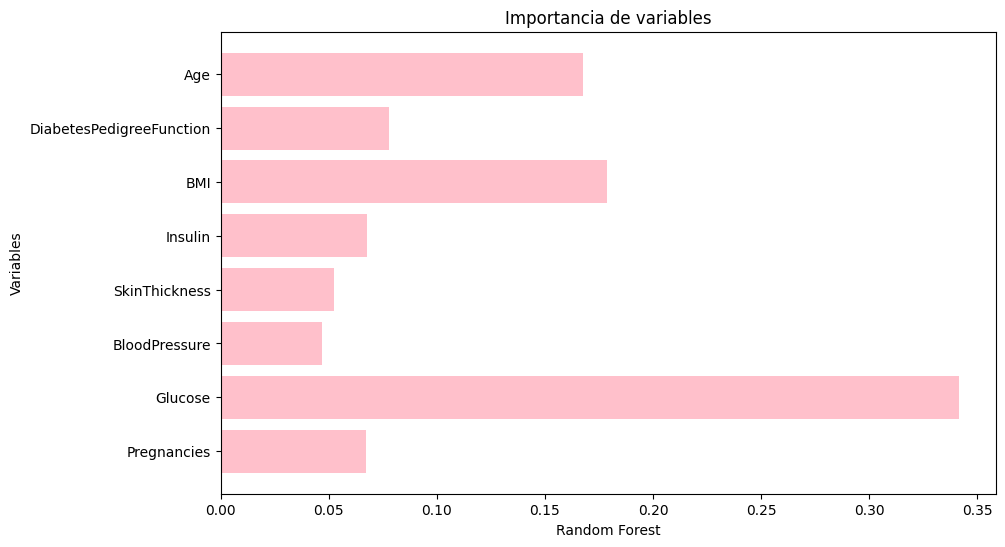

In [107]:
# Análisis de importancia
importances = mejor_rf.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X.columns, importances, color='pink')

plt.title("Importancia de variables")
plt.xlabel("Random Forest")
plt.ylabel("Variables")
plt.show()



Análisis de Importancia de Variables (Random Forest)

El gráfico revela las características tienen mayor peso en la capacidad predictiva del modelo:

- Variables dominantes: La Edad (Age) y el DiabetesPedigreeFunction son los factores más determinantes. Esto indica que el modelo encuentra patrones fuertes en cómo evoluciona la probabilidad de padecer diabetes a lo largo de los años y cómo influyen los antecedentes familiares.

-  Influencia física: El IMC (BMI) aparece como la tercera variable más importante, confirmando la estrecha relación entre el índice de masa corporal y la enfermedad.

- Variables de menor impacto: Factores como las Embarazos (Pregnancies) o el nivel de Insulina tienen una importancia comparativamente menor en este modelo específico. Esto no significa que no sean importantes médicamente, sino que, para los datos proporcionados, el modelo encuentra información más discriminativa en las variables de edad y genética.

In [108]:
# comparacion

acc_arbol_final = accuracy_score(y_test, clf.predict(X_test)) 

acc_rf_final = accuracy_score(y_test, mejor_rf.predict(X_test))

# se crea la tabla
import pandas as pd
comparativa = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Random Forest'],
    'Accuracy': [acc_arbol_final, acc_rf_final],
    'Diferencia': [0, acc_rf_final - acc_arbol_final]
})

print("--- RESULTADOS DE LA COMPARACIÓN ---")
print(comparativa.to_string(index=False))

--- RESULTADOS DE LA COMPARACIÓN ---
           Modelo  Accuracy  Diferencia
Árbol de Decisión  0.727273    0.000000
    Random Forest  0.772727    0.045455


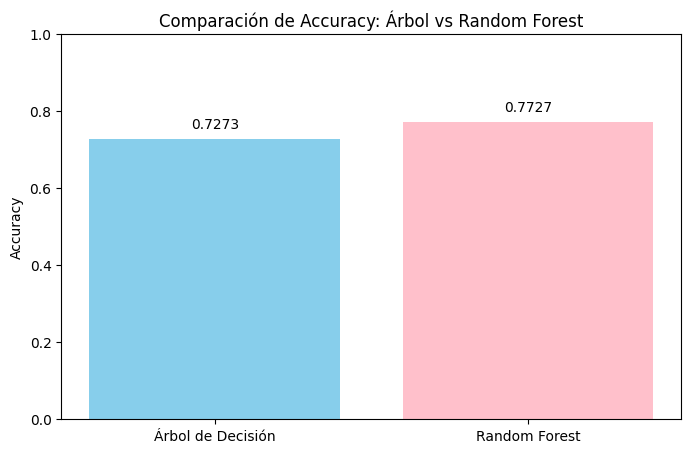

In [110]:
import matplotlib.pyplot as plt

# Gráfico
plt.figure(figsize=(8, 5))
barras = plt.bar(comparativa['Modelo'], comparativa['Accuracy'], color=['skyblue', 'pink'])

plt.title('Comparación de Accuracy: Árbol vs Random Forest')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  

# se añaden las etiquetas de texto sobre cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.02, round(yval, 4), ha='center', va='bottom')

plt.show()

Análisis del Gráfico Comparativo

- Interpretación visual: Se observa claramente que el modelo Random Forest (barra rosa) tiene una altura superior al Árbol de Decisión (barra azul). Esto indica que el modelo de ensemble ha logrado una mayor capacidad para clasificar correctamente los datos de prueba.

- Significado del incremento: Pasar de una precisión (Accuracy) de aproximadamente 0.72 a 0.77 representa una mejora sustancial en la predicción. Esto valida la hipótesis de que, en este caso, un solo árbol de decisión era insuficiente para capturar toda la complejidad de los datos.

- ¿Por qué Random Forest es mejor?: El Random Forest ha logrado mitigar los errores o el sobreajuste (overfitting) que probablemente presentaba el árbol único, al promediar las decisiones de múltiples árboles entrenados con diferentes subconjuntos de datos.

In [95]:
# Guardar el modelo 
pickle.dump(mejor_rf, open('modelo_random_forest_diabetes.pkl', 'wb'))
print("\nModelo guardado correctamente.")


Modelo guardado correctamente.


Conclusión

El ultimo gráfico demuestra que la técnica de Random Forest, combinada con la optimización de hiperparámetros mediante GridSearchCV, ha sido exitosa. Psando de un modelo básico a uno más robusto que ahora es capaz de identificar correctamente a un 77% de los pacientes en el conjunto de prueba.